# Customer Segmentation & Recommendation System

Ce notebook montre comment passer d’un historique de transactions e-commerce à :
- une segmentation clients basée sur RFM et K-means ;
- un système simple de recommandation de produits par segment.

Les données proviennent du dataset **“Customer Segmentation & Recommendation System”** publié sur Kaggle par Farzad Nekouei.


### Source des données

Les données utilisées dans ce projet proviennent du jeu de données  
**“Customer Segmentation & Recommendation System”**, publié sur **Kaggle** par Farzad Nekouei.

Elles contiennent des transactions d’un détaillant en ligne (numéro de facture, produit, quantité, prix unitaire, client, pays, etc.), sur la période 2010–2011.


## Chargement des données

Dans cette section, nous importons le jeu de données transactionnelles depuis un fichier local (CSV ou Excel) et vérifions rapidement sa structure.  
L’objectif est de disposer d’un DataFrame brut (`df_raw`) qui servira de point de départ avant le nettoyage et la création des indicateurs clients.


In [1]:
import pandas as pd

# # Chemin vers le fichier source
file_path = "data.csv"

# # Lecture du fichier
recommend = pd.read_csv(file_path, encoding="latin1")  # ou encoding="ISO-8859-1"

In [2]:
recommend.shape

(541909, 8)

In [3]:
# Aperçu rapide
recommend.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
# Always start from a working copy
df = recommend.copy()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
print(df.isna().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [7]:
# 3) Convert InvoiceDate to datetime (very important for RFM & recency)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [8]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Nettoyage & préparation des transactions

Objectif : obtenir un tableau de transactions propre (`df_clean`) qui servira à l’EDA, au RFM et à K-means.
- Suppression des lignes sans `CustomerID` (impossible à segmenter).
- Gestion des valeurs manquantes (Description).
- Correction des types (CustomerID en entier).
- Suppression des doublons exacts.


In [9]:
# NETTOYAGE DE DATA
# On crée une copie pour le nettoyage
df_clean = df.copy()

In [10]:
# 1) Revoir les valeurs manquantes
df_clean.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
# 2) Supprimer les lignes sans CustomerID (on ne peut pas les segmenter)
df_clean = df_clean.dropna(subset=["CustomerID"])

In [12]:
# 1) Revoir les valeurs manquantes
df_clean.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [13]:
# 3) Remplir les Description manquantes par un texte générique
df_clean["Description"] = df_clean["Description"].fillna("MISSING_DESCRIPTION")

# 4) S'assurer que CustomerID est bien de type entier
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)

# 5) Vérification après nettoyage des NA
print("\n=== MISSING VALUES APRES ===")
print(df_clean.isna().sum())

print("\nNouvelle taille du dataset :", df_clean.shape)


=== MISSING VALUES APRES ===
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Nouvelle taille du dataset : (406829, 8)


In [14]:
# 1) Nombre de doublons exacts
dup_count = df_clean.duplicated().sum()
print("Nombre de lignes dupliquées :", dup_count)

Nombre de lignes dupliquées : 5225


In [15]:
# 2) Suppression des doublons
df_clean = df_clean.drop_duplicates()

In [16]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


## 3. Analyse exploratoire (EDA)

### 3.1 Construction du montant de transaction
### 3.2 KPIs globaux (clients, produits, pays, revenu total)
### 3.3 Produits les plus vendus (top produits)
### 3.4 Répartition du revenu par pays
### 3.5 KPIs mensuels (revenu, clients actifs, ARPU)


In [17]:
# On part de df_clean
df_eda = df_clean.copy()

# 1) Montant de chaque ligne (comme un "transaction amount" )
df_eda["TotalPrice"] = df_eda["Quantity"] * df_eda["UnitPrice"]

In [18]:
# 2) KPIs de base
n_rows = len(df_eda)
n_customers = df_eda["CustomerID"].nunique()
n_products = df_eda["StockCode"].nunique()
n_countries = df_eda["Country"].nunique()
total_revenue = df_eda["TotalPrice"].sum()

In [19]:
print("Nombre de lignes (transactions) :", n_rows)
print("Nombre de clients uniques       :", n_customers)
print("Nombre de produits uniques      :", n_products)
print("Nombre de pays                  :", n_countries)
print("Revenu total                    :", round(total_revenue, 2))

Nombre de lignes (transactions) : 401604
Nombre de clients uniques       : 4372
Nombre de produits uniques      : 3684
Nombre de pays                  : 37
Revenu total                    : 8278519.42


In [20]:
# Ce que ça fait :
# TotalPrice : pour chaque ligne, on calcule 👉 montant de la transaction = quantité × prix unitaire
# Comme un montant de transaction M-Pesa (par ex. 10 000 SLL).

# n_rows : nombre total de lignes = nombre de transactions dans les données.
# n_customers : nombre de CustomerID différents = nombre de clients uniques → chez moi : 4372 clients.
# n_products : nombre de StockCode différents = nombre de produits différents → 3684 produits.
# n_countries : nombre de pays différents = nombre de pays desservis → 37 pays.

# total_revenue : somme de TotalPrice = chiffre d’affaires total → environ 8 275 819.42 (en livres dans ce dataset).
# 👉 En résumé business : On a environ 4372 clients, 3684 produits, 37 pays et plus de 8,2 M de chiffre d’affaires sur la période.

# ce bloc prmet de compter la base de clients, compter la base de produits / services, mesurer le revenu total,
# ce qui est la base pour parler de pénétration produit et de croissance.

## adoption produit (top produits)
### On va voir quels sont les produits les plus vendus.

In [21]:
# Top 10 produits par nombre de lignes (transactions)
top_products_count = (
    df_eda
    .groupby(["StockCode", "Description"])
    .agg(
        transactions=("InvoiceNo", "nunique"),
        quantity_sold=("Quantity", "sum"),
        revenue=("TotalPrice", "sum")
    )
    .sort_values("transactions", ascending=False)
    .head(10)
)

top_products_count


,,transactions,quantity_sold,revenue
StockCode,Description,,,
85123A,WHITE HANGING HEART T-LIGHT HOLDER,2013,34128,93767.80
22423,REGENCY CAKESTAND 3 TIER,1884,11529,132567.70
85099B,JUMBO BAG RED RETROSPOT,1643,44963,83056.52
47566,PARTY BUNTING,1399,15015,67628.43
84879,ASSORTED COLOUR BIRD ORNAMENT,1385,35215,56331.91
20725,LUNCH BAG RED RETROSPOT,1329,17024,27050.40
22720,SET OF 3 CAKE TINS PANTRY DESIGN,1218,6857,32573.15
POST,POSTAGE,1194,3002,66710.24
20727,LUNCH BAG BLACK SKULL.,1073,11128,17764.60


In [22]:
# Ce que ça fait :
# groupby(["StockCode", "Description"])→ On rassemble toutes les lignes du même produit.
# .agg(...)
# transactions=("InvoiceNo", "nunique") → on compte le nombre de factures différentes où le produit apparaît,  = combien de fois ce produit a été acheté (nombre de paniers).
# quantity_sold=("Quantity", "sum") → on additionne toutes les quantités vendues,  = nombre total d’unités vendues.
# revenue=("TotalPrice", "sum") → on additionne le montant total, = revenu total généré par ce produit.
# .sort_values("transactions", ascending=False) → on classe les produits du plus acheté au moins acheté (en nombre de transactions).
# .head(10) → on garde les 10 produits les plus achetés.
# Dans notre tableau, on voit par exemple :
# WHITE HANGING HEART T-LIGHT HOLDER transactions ≈ 2013, quantity_sold ≈ 34 128, revenue ≈ 97 687.80
# Ça veut dire : Ce produit apparaît dans 2013 factures, 34k unités vendues, pour ~97k de chiffre d’affaires.

# Ici on apprend à  mesurer l’adoption d’un produit (combien de clients / transactions), voir quels sont les produits “stars”, préparer le terrain pour des reco produits par segment.

### répartition par pays (analogue à “par région”)

In [23]:
# Agrégation par pays
country_summary = (
    df_eda
    .groupby("Country")
    .agg(
        customers=("CustomerID", "nunique"),
        transactions=("InvoiceNo", "nunique"),
        total_quantity=("Quantity", "sum"),
        revenue=("TotalPrice", "sum")
    )
    .sort_values("revenue", ascending=False)
)

country_summary.head(10)


,customers,transactions,total_quantity,revenue
Country,,,,
United Kingdom,3950,19857,3994870,6747156.154
Netherlands,9,101,200128,284661.540
EIRE,3,319,136187,250001.780
Germany,95,603,117341,221509.470
France,87,458,109806,196626.050
Australia,9,69,83643,137009.770
Switzerland,21,71,29778,55739.400
Spain,31,105,26817,54756.030
Belgium,25,119,23152,40910.960


In [24]:
df_eda.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [25]:
# Ce que ça fait :
# groupby("Country") → On regroupe toutes les transactions par pays.

# .agg(...) :
# customers : nombre de clients uniques par pays.
# transactions : nombre de factures / transactions par pays.
# total_quantity : quantité totale de produits envoyés dans ce pays.
# revenue : chiffre d’affaires total pour ce pays.
# sort_values("revenue", ascending=False) → on trie les pays du plus gros revenu au plus petit.
# Dans mon tableau, tu vois par exemple : United Kingdom: customers ≈ 3950, transactions ≈ 19 857, revenue ≈ 6 747 516.15
# Donc :
# Le Royaume-Uni concentre la grande majorité des clients et du chiffre d’affaires. Les autres pays (Netherlands, EIRE, Germany, France, etc.) apportent des revenus plus faibles.

# Ce tableau, c’est déjà : une vision par région/pays, on peut repérer les pays forts/faibles :
# fortes ventes → forte pénétration, faibles ventes → opportunités de croissance
# on peut plus tard : calculer un ARPU par pays (revenue / nombre de clients), repérer les pays avec beaucoup de clients mais faible revenu → cibles pour activation / upsell.
# En résumé simple
# J'ai calculé la taille du business (transactions, clients, produits, pays, revenu).
# J'ai identifié les produits les plus adoptés (top 10 produits).
# J'ai vu la contribution de chaque pays au chiffre d’affaires.

# C’est exactement le genre de diagnostic de base qu’un analyste M-Pesa ferait avant de parler de : croissance, pénétration produit, priorités régionales, campagnes marketing.

## 1) KPI par mois (revenu, clients actifs, ARPU): Idée : dans M-Pesa, on suit souvent par mois ou par semaine :
#### combien de revenus, combien de clients actifs,

In [26]:
# On repart de df_eda
df_time = df_eda.copy()

# S'assurer que la date est bien en datetime (normalement c'est déjà fait)
df_time["InvoiceDate"] = pd.to_datetime(df_time["InvoiceDate"])

# 1) Créer une colonne Année-Mois (format AAAA-MM)
df_time["YearMonth"] = df_time["InvoiceDate"].dt.to_period("M").astype(str)

# 2) KPI par mois
monthly_summary = (
    df_time
    .groupby("YearMonth")
    .agg(
        revenue=("TotalPrice", "sum"),            # revenu total du mois
        active_customers=("CustomerID", "nunique"),  # clients uniques ce mois
        transactions=("InvoiceNo", "nunique")     # nombre de factures
    )
    .sort_index()
)

# 3) ARPU mensuel = revenu du mois / nombre de clients actifs ce mois
monthly_summary["ARPU"] = monthly_summary["revenue"] / monthly_summary["active_customers"]

monthly_summary

## ARPU: On ajoute une colonne ARPU = revenue / active_customers.C’est le revenu moyen par client actif pour ce mois.
## Ça veut dire : En décembre 2010, 948 clients différents ont acheté, pour un total d’environ 552k de revenus, soit en moyenne ~583 par client actif.

,revenue,active_customers,transactions,ARPU
YearMonth,,,,
2010-12,552372.860,948,1708,582.671793
2011-01,473731.900,783,1236,605.021584
2011-02,435534.070,798,1202,545.782043
2011-03,578576.210,1020,1619,567.231578
2011-04,425222.671,899,1384,472.995185
2011-05,647011.670,1079,1849,599.640102
2011-06,606862.520,1051,1707,577.414386
2011-07,573112.321,993,1593,577.152388
2011-08,615078.090,980,1544,627.630704


## 4. Construction des indicateurs clients (RFM)

### 4.1 Recency : nombre de jours depuis le dernier achat
### 4.2 Table RFM complète par client (Recency, Frequency, Monetary)


In [27]:
from datetime import timedelta

# 1) Date de référence = dernier jour + 1
snapshot_date = df_time["InvoiceDate"].max() + timedelta(days=1)
print("Date de référence :", snapshot_date)

# 2) Agrégation par client
customer_recency = (
    df_time
    .groupby("CustomerID")
    .agg(
        last_purchase=("InvoiceDate", "max"),
        total_revenue=("TotalPrice", "sum"),
        transactions=("InvoiceNo", "nunique")
    )
)

# 3) Calcul de la recency en jours
customer_recency["recency_days"] = (snapshot_date - customer_recency["last_purchase"]).dt.days

customer_recency.head()


Date de référence : 2011-12-10 12:50:00


,last_purchase,total_revenue,transactions,recency_days
CustomerID,,,,
12346,2011-01-18 10:17:00,0.00,2,326
12347,2011-12-07 15:52:00,4310.00,7,2
12348,2011-09-25 13:13:00,1797.24,4,75
12349,2011-11-21 09:51:00,1757.55,1,19
12350,2011-02-02 16:01:00,334.40,1,310


In [28]:
df_time.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12


### Pour chaque client (CustomerID), on calcule : last_purchase : date de son dernier achat, total_revenue : somme de tout ce qu’il a dépensé, transactions : nombre de factures (combien de fois il a acheté)
### Exemple dans le tableau dessous : Client 12347, last_purchase = 2011-12-07, total_revenue = 4310, transactions = 7
### C’est un bon client, récent, avec plusieurs achats.

In [29]:
# Tu crées une fonction qui transforme un nombre de jours (recency_days) en catégorie : ≤ 30 jours → “Active (≤30j)” entre 31 et 90 jours → “Warm (31–90j)” 
# (clients un peu dormants, mais pas perdus), > 90 jours → “Inactif (>90j)” (risque de churn fort)

def label_recency(days):
    if days <= 30:
        return "Active (≤30j)"
    elif days <= 90:
        return "Warm (31–90j)"
    else:
        return "Inactif (>90j)"

customer_recency["recency_segment"] = customer_recency["recency_days"].apply(label_recency)

customer_recency["recency_segment"].value_counts()

# Sur ta base de clients :
# 1695 ont acheté dans les 30 derniers jours → base très active
# 1223 n’ont rien acheté depuis environ 1–3 mois → à surveiller / à relancer
# 1454 n’ont rien acheté depuis plus de 3 mois → fort risque de churn

recency_segment
Active (≤30j)     1695
Inactif (>90j)    1454
Warm (31–90j)     1223
Name: count, dtype: int64

### RFM complet (Recency–Frequency–Monetary), qui sera la base pour la segmentation clients (K-means) et pour montrer que tu sais faire de la segmentation comme dans le job M-Pesa.

In [30]:
## tableau RFM par client

# On repart de customer_recency
rfm = customer_recency.copy()

# Renommer les colonnes pour que ce soit clair
rfm = rfm.rename(
    columns={
        "recency_days": "Recency",
        "transactions": "Frequency",
        "total_revenue": "Monetary"
    }
)

# Garder les colonnes importantes dans l'ordre
rfm = rfm[["last_purchase", "Recency", "Frequency", "Monetary"]]

# Aperçu
rfm.head()

# Recency = nombre de jours depuis le dernier achat
# Frequency = nombre de factures
# Monetary = total dépensé
# Depuis quand il est venu, combien de fois, et combien il rapporte.” ex. client 12347 → Recency = 2 → il a acheté il y a 2 jours → très récent.

,last_purchase,Recency,Frequency,Monetary
CustomerID,,,,
12346,2011-01-18 10:17:00,326,2,0.00
12347,2011-12-07 15:52:00,2,7,4310.00
12348,2011-09-25 13:13:00,75,4,1797.24
12349,2011-11-21 09:51:00,19,1,1757.55
12350,2011-02-02 16:01:00,310,1,334.40


In [31]:
# On regarde les min, max, médianes, etc. pour R, F, M :
rfm[["Recency", "Frequency", "Monetary"]].describe()

# mean (moyenne)
# Recency ≈ 92 jours → en moyenne, le dernier achat remonte à ~3 mois.
# Frequency ≈ 5 → un client achète en moyenne 5 fois.
# Monetary ≈ 1893 → un client dépense en moyenne ~1893 sur toute la période.

,Recency,Frequency,Monetary
count,4372.000000,4372.000000,4372.000000
mean,92.047118,5.075480,1893.531433
std,100.765435,9.338754,8218.696204
min,1.000000,1.000000,-4287.630000
25%,17.000000,1.000000,291.795000
50%,50.000000,3.000000,644.070000
75%,143.000000,5.000000,1608.335000
max,374.000000,248.000000,279489.020000


In [32]:
rfm.head()

,last_purchase,Recency,Frequency,Monetary
CustomerID,,,,
12346,2011-01-18 10:17:00,326,2,0.00
12347,2011-12-07 15:52:00,2,7,4310.00
12348,2011-09-25 13:13:00,75,4,1797.24
12349,2011-11-21 09:51:00,19,1,1757.55
12350,2011-02-02 16:01:00,310,1,334.40


In [33]:
## Avec ce simple tableau RFM, tu peux déjà :
# repérer les gros contributeurs (Frequency et Monetary élevés),
# repérer les clients en risque de churn (Recency très élevée),
# préparer des campagnes ciblées (ex : réactiver les clients avec Recency > 90j).
# C’est exactement ce qu’on attend d’un analyste growth / CVM pour M-Pesa.

In [34]:
## “Les clients avec un revenu net ≤ 0 représentent des profils à retours importants ou des annulations.
# Ils ne sont pas inclus dans la segmentation RFM classique mais sont suivis séparément comme indicateur de qualité / risque.”

# 1️⃣ Nettoyer les clients avec revenu négatif ou nul

# On part de rfm
rfm_pos = rfm[rfm["Monetary"] > 0].copy()

print("Taille avant :", rfm.shape)
print("Taille après  :", rfm_pos.shape)

rfm_pos[["Recency", "Frequency", "Monetary"]].describe()

Taille avant : (4372, 4)
Taille après  : (4322, 4)


,Recency,Frequency,Monetary
count,4322.000000,4322.000000,4.322000e+03
mean,90.343591,5.115687,1.918498e+03
std,99.133565,9.384459,8.262490e+03
min,1.000000,1.000000,1.776357e-15
25%,17.000000,1.000000,3.005975e+02
50%,49.500000,3.000000,6.533250e+02
75%,138.000000,6.000000,1.624118e+03
max,374.000000,248.000000,2.794890e+05


## 5. Scoring RFM et mini-segmentation

- Création de scores R, F, M sur une échelle de 1 à 5.
- Calcul d’un score global `RFM_score`.
- Découpage en 4 segments business simples : VIP / High value, Loyal, Occasional, At risk / Low value.


In [35]:
# pd.qcut = quantile cut: Il coupe une variable numérique en k groupes qui contiennent à peu près le même nombre de clients.
# Exemple : qcut(..., 5, ...) → crée 5 groupes ≈ 20% des clients dans chaque groupe (0–20%, 20–40%, 40–60%, 60–80%, 80–100%).
# Donc : pour Recency : les 20% de clients les plus récents = un groupe, les 20% suivants = 2ᵉ groupe, etc.
# pour Frequency ou Monetary : les 20% qui dépensent le moins / achètent le moins, jusqu’aux 20% qui dépensent le plus.

In [36]:
# Score R (Recency)
# On prend la colonne Recency.
# 5 = on veut 5 groupes (20% des clients dans chaque groupe environ).
# Par défaut, qcut crée des groupes du plus petit au plus grand.
# Pour Recency : Petit Recency = client très récent → bon.
# Grande Recency = client très ancien → moins bon.
# C’est pourquoi on met les labels inversés : le groupe avec Recency la plus petite reçoit 5, le groupe suivant → 4, … jusqu’au groupe avec Recency la plus grande → 1.

# Dans notre formule: 
# R_score = 5 si le client est dans les 20% les plus récents, R_score = 4 si dans les 20–40% suivants, R_score = 1 s’il est dans les 20% les plus anciens.
    
rfm_pos["R_score"] = pd.qcut(
    rfm_pos["Recency"], 
    5, 
    labels=[5, 4, 3, 2, 1],    # 5 = très récent, 1 = très ancien
    duplicates="drop"
)


In [37]:
# Ici : plus la Frequency est grande, plus le client est fidèle.
# On veut donc que le plus petit groupe ait 1 et le plus grand 5.
# Comme qcut va du plus petit au plus grand : groupe “peu fréquents” → 1, groupe “moyens” → 2, 3, 4, groupe “très fréquents” → 5.

# Score F : plus de transactions = meilleur score

# 1) On crée les classes (bins) avec qcut, sans labels pour éviter l'erreur
f_bins = pd.qcut(
    rfm_pos["Frequency"],
    5,
    duplicates="drop"
)

# 2) On récupère le code de classe (0,1,2,...) et on le transforme en score 1,2,3,...
rfm_pos["F_score"] = f_bins.cat.codes + 1   # 1 = peu fréquent, max = très fréquent


In [38]:
# Score M (Monetary)
# Même logique que pour Frequency : petit Monetary = petit score (1), grand Monetary = gros score (5).
rfm_pos["M_score"] = pd.qcut(
    rfm_pos["Monetary"], 
    5, 
    labels=[1, 2, 3, 4, 5],    # 5 = gros contributeur
    duplicates="drop"
)


In [39]:
# Conversion en entier + score global
# qcut retourne des catégories, on les convertit en int pour pouvoir faire des maths.

rfm_pos["R_score"] = rfm_pos["R_score"].astype(int)
rfm_pos["F_score"] = rfm_pos["F_score"].astype(int)
rfm_pos["M_score"] = rfm_pos["M_score"].astype(int)

In [40]:
# On additionne les trois scores.
# Minimum = 1+1+1 = 3
# Maximum = 5+5+5 = 15.

# 👉 Interprétation :
# RFM_score ≈ 13–15 → clients VIP : récents, fréquents, gros revenus.
# RFM_score ≈ 3–6 → clients faibles / à risque.

rfm_pos["RFM_score"] = (
    rfm_pos["R_score"] + 
    rfm_pos["F_score"] + 
    rfm_pos["M_score"]
)


In [41]:
# vérifier la distribution

rfm_pos["RFM_score"].value_counts().sort_index()
rfm_pos[["R_score", "F_score", "M_score", "RFM_score"]].head()


,R_score,F_score,M_score,RFM_score
CustomerID,,,,
12347,5,3,5,13
12348,2,2,4,8
12349,4,1,4,9
12350,1,1,2,4
12352,3,4,4,11


In [42]:
rfm_pos[["Recency", "Frequency", "Monetary",
         "R_score", "F_score", "M_score", "RFM_score"]].head()


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
CustomerID,,,,,,,
12347,2,7,4310.00,5,3,5,13
12348,75,4,1797.24,2,2,4,8
12349,19,1,1757.55,4,1,4,9
12350,310,1,334.40,1,1,2,4
12352,36,11,1545.41,3,4,4,11


In [43]:
# Avec le scoring RFM, j’identifie les clients VIP (RFM ≥ 13), les clients fidèles (10–12), et les clients à risque (RFM ≤ 6).
# Par exemple, le client 12347 est très récent et génère un revenu élevé (score 13), ce qui en fait une cible idéale pour les offres de fidélisation ou de cross-sell.
# À l’inverse, le client 12350 (score 4) est inactif depuis longtemps, avec une faible fréquence et un faible montant, ce qui en fait une cible plutôt pour des campagnes de réactivation ou on peut l’accepter comme churné.

# Client 12347:
# Recency = 2 jours → très récent → R_score = 5 (max).
# Frequency = 7 → il est venu plusieurs fois → F_score = 3 (correct, mais pas le plus fréquent).
# Monetary = 4310 → gros montant → M_score = 5.
# RFM_score = 13 → client de très forte valeur (récent + dépense beaucoup).
# 👉 Type “VIP / High value recent”.

# Client 12350:
# Recency = 310 jours → dernier achat il y a très longtemps → R_score = 1.
# Frequency = 1 → il n’a acheté qu’une seule fois → F_score = 1.
# Monetary = 334.40 → petit montant → M_score = 2.
# RFM_score = 4 → client de faible valeur, inactif.
# 👉 Type “Ancien client, faible engagement, proche du churn”.

# Client 12352
# Recency = 36 → récent mais pas tout à fait top → R_score = 3.
# Frequency = 11 → il achète souvent → F_score = 4.
# Monetary = 1545 → bon montant → M_score = 4.
# RFM_score = 11 → bon client fidèle, pas VIP mais très intéressant.

In [44]:
# 3️⃣ Mini-segmentation RFM (option simple avant K-means): Avant d’attaquer K-means, on peut déjà créer des catégories simples à partir de RFM_score.

def segment_rfm(score):
    if score >= 13:
        return "VIP / High value"
    elif score >= 10:
        return "Loyal"
    elif score >= 7:
        return "Occasional"
    else:
        return "At risk / Low value"

rfm_pos["RFM_segment"] = rfm_pos["RFM_score"].apply(segment_rfm)

rfm_pos["RFM_segment"].value_counts()


RFM_segment
At risk / Low value    1698
Occasional             1151
Loyal                   876
VIP / High value        597
Name: count, dtype: int64

In [45]:
# En mots simples :
# VIP / High value (597), RFM_score ≥ 13: Clients récents, fréquents, qui dépensent beaucoup. → à chouchouter : offres de fidélité, cross-sell, early access, etc.
# Loyal (876), RFM entre 10 et 12: Clients réguliers, bonne valeur, mais pas au niveau “VIP”. → à entretenir : programmes de points, bundles, remises légères.
# Occasional (1151), RFM entre 7 et 9: Achètent de temps en temps ou montants moyens. → à activer : campagnes pour augmenter la fréquence ou le panier.
# At risk / Low value (1698), RFM ≤ 6: Peu ou plus du tout actifs, peu de revenu. → soit cible de réactivation, soit considérés comme quasiment churn.

# Lien M-Pesa :
# Tu viens de construire exactement un framework de segmentation / loyalty comme dans l’annonce :
,# quels clients prioriser pour la rétention, lesquels pour l’activation, lesquels pour le cross-sell.

In [46]:
# profiler chaque segment: Avant de passer à K-means, on peut résumer les RFM moyens par segment (très utile sur ton notebook + en entretien) :

segment_profile = (
    rfm_pos
    .groupby("RFM_segment")
    .agg(
        clients=("RFM_score", "count"),
        avg_recency=("Recency", "mean"),
        avg_frequency=("Frequency", "mean"),
        avg_monetary=("Monetary", "mean")
    )
    .sort_values("clients", ascending=False)
)

segment_profile


,clients,avg_recency,avg_frequency,avg_monetary
RFM_segment,,,,
At risk / Low value,1698,169.993522,1.485866,315.287062
Occasional,1151,60.211121,2.911381,869.516458
Loyal,876,30.897260,6.281963,2040.428664
VIP / High value,597,9.123953,17.978224,8321.879698


In [47]:
rfm_pos.head()

,last_purchase,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_segment
CustomerID,,,,,,,,,
12347,2011-12-07 15:52:00,2,7,4310.00,5,3,5,13,VIP / High value
12348,2011-09-25 13:13:00,75,4,1797.24,2,2,4,8,Occasional
12349,2011-11-21 09:51:00,19,1,1757.55,4,1,4,9,Occasional
12350,2011-02-02 16:01:00,310,1,334.40,1,1,2,4,At risk / Low value
12352,2011-11-03 14:37:00,36,11,1545.41,3,4,4,11,Loyal


In [48]:
# Comment lire ce profil de segments

# At risk / Low value (1698 clients)

# Recency moyenne ~170 jours → ils n’ont rien acheté depuis très longtemps. 
# Frequency ~1,5 → 1–2 achats seulement.
# Monetary ~315 → petit revenu. ➜ Clients faibles et quasi churnés. Sur M-Pesa : base à réactiver ou à accepter comme perdue.

# Occasional (1151 clients), Recency ~60 jours → revenus il y a 2 mois. Frequency ~3 → quelques achats. Monetary ~870 → revenu moyen.➜ Clients occasionnels : pas perdus, mais pas encore fidèles. Cibles pour augmenter la fréquence ou le panier.

# Loyal (876 clients), Recency ~31 jours → assez récents. Frequency ~6,3 → reviennent souvent. Monetary ~2040 → bon revenu. ➜ Clients fidèles : bons contributeurs, à entretenir (programmes de fidélité, offres spéciales).

# VIP / High value (597 clients), Recency ~9 jours → achats très récents. Frequency ~18 → très fréquents. Monetary ~8322 → très gros revenu.➜ Top clients. À protéger : service premium, offres exclusives, cross-sell.

# pour le poste M-Pesa:

# un cadre de segmentation basé sur des indicateurs simples (R, F, M), une vue claire du poids de chaque segment dans la base, un point de départ pour des actions marketing :
# VIP → rétention / cross-sell
# Loyal → fidélisation
# Occasional → activation
# At risk → réactivation ciblée ou churn.

# C’est exactement ce qu’ils appellent dans l’offre : “segmentation, loyalty, cross-sell frameworks” et “data-backed recommendations”.

## 6. Segmentation K-means

- Préparation des features RFM (log-transform + standardisation).
- Sélection d’un nombre de clusters à l’aide des méthodes Elbow et Silhouette.
- Entraînement du modèle K-means et profilage des clusters (taille, Recency moyenne, fréquence, valeur).


In [49]:
# Préparer les variables pour K-means

import numpy as np
from sklearn.preprocessing import StandardScaler

# 1) On prépare un DataFrame de features
features = rfm_pos[["Recency", "Frequency", "Monetary"]].copy()

# 2) Log-transform pour limiter l'effet des très gros clients (éviter que K-means soit dominé par eux)
# np.log1p(x) = log(1 + x) réduit l’écart entre petits et très grands chiffres, garde le même ordre : si A > B avant, A > B après.
# On ne remplace pas Frequency et Monetary. On crée juste de nouvelles colonnes pour le modèle (Frequency_log, Monetary_log). Pour interpréter les clusters, on utilisera toujours les vraies valeurs (R, F, M) dans rfm_pos.
features["Recency_log"] = features["Recency"]          # on peut garder Recency brut
features["Frequency_log"] = np.log1p(features["Frequency"])   # log(1 + F)
features["Monetary_log"] = np.log1p(features["Monetary"])     # log(1 + M)

# 3) On ne garde que les colonnes log pour le clustering
X = features[["Recency_log", "Frequency_log", "Monetary_log"]]

# 4) Standardisation (moyenne 0, écart-type 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]   # juste pour vérifier la forme


array([[-0.89126032,  0.85451058,  1.43140291],
       [-0.15479486,  0.21730915,  0.73951409],
       [-0.71975466, -1.02494031,  0.72185305],
       [ 2.21601861, -1.02494031, -0.58928103],
       [-0.54824901,  1.40421472,  0.6201277 ]])

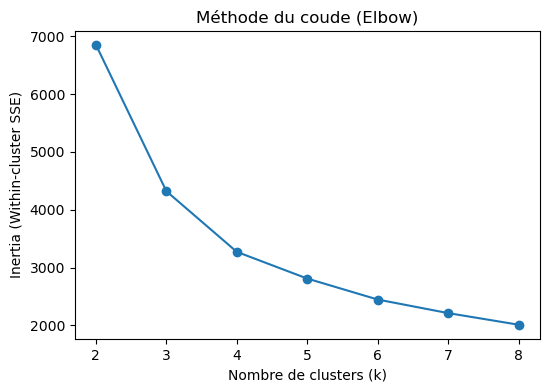

In [50]:
# Choisir le nombre de clusters (K)

# On va tester K de 2 à 8 et regarder : inertie (Elbow method) → plus c’est bas, mieux c’est, silhouette score → plus c’est haut, mieux c’est (entre -1 et 1)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouettes = []
K_values = range(2, 9)

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# 1) Courbe Elbow
plt.figure(figsize=(6,4))
plt.plot(K_values, inertias, marker="o")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertia (Within-cluster SSE)")
plt.title("Méthode du coude (Elbow)")
plt.show()


In [51]:
# Le choix de K
# Sur notre Elbow :
# entre k = 2 et k = 3, la courbe descend beaucoup ;
# entre k = 3 et k = 4, elle descend encore pas mal ;
# après k = 4, la courbe devient beaucoup plus plate : 4→5, 5→6, 6→7, 7→8 : ça baisse toujours, mais petit à petit.

# Visuellement, on voit une forme de “L” renversé : la barre verticale (forte descente) ≈ de 2 à 4 la barre horizontale (descente douce) ≈ après 4
# 👉 Le “angle” du L est autour de k = 4.
# C’est ça qu’on appelle le coude , le plus petit k après lequel ajouter des clusters n’apporte plus un gros gain.

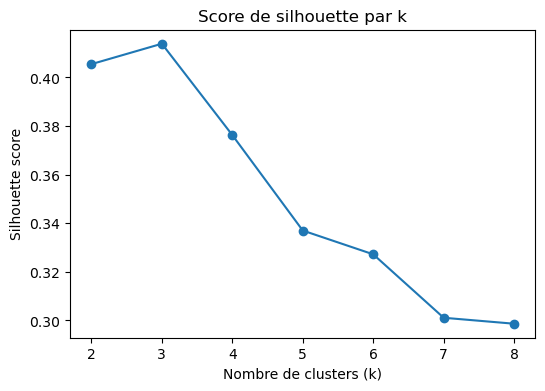

In [52]:

# 2) Courbe Silhouette
plt.figure(figsize=(6,4))
plt.plot(K_values, silhouettes, marker="o")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Score de silhouette par k")
plt.show()

In [53]:
# 1️⃣ C’est quoi le silhouette score ?
# Pour chaque k, le silhouette score mesure : cohésion : les points d’un même cluster sont proches entre eux, séparation : les clusters sont bien séparés les uns des autres.
# Le score est entre -1 et 1 : proche de 1 → très bons clusters (bien compacts et bien séparés), autour de 0 → les clusters se chevauchent, pas très clairs, négatif → les points sont probablement dans le mauvais cluster.
# 👉 Donc plus le score est grand, mieux c’est.
# k = 2 → ~0.41
# k = 3 → ~0.415 (meilleur score)
# k = 4 → ~0.378 (baisse assez forte)
# k = 5 → ~0.338 (ça baisse encore, mais un peu moins)

# Donc : meilleure valeur purement statistique : k = 3, à partir de k = 4, le score diminue, les clusters deviennent un peu moins nets
#⃣  Comment choisir avec ça ?
# On combine les deux graphes + le métier :
# Elbow : coude vers 3–4 (après 4, l’amélioration est faible).
# Silhouette : meilleur score à 3, raisonnable à 4, puis de plus en plus faible.
# Métier / business : tu as déjà une logique naturelle à 4 segments (VIP, Loyal, Occasional, At risk).

# 👉 Du coup, tu peux dire :
# Statistiquement, k = 3 donne le meilleur silhouette.
# Mais k = 4 garde un silhouette encore correct (~0.38) et correspond mieux à une segmentation business claire (VIP / Loyal / Occasional / At risk).

# Pour un projet portfolio + entretien M-Pesa, la phrase idéale : “L’Elbow et le silhouette suggèrent un k entre 3 et 4.
# J’ai choisi 4 clusters : le score de silhouette reste bon et cela correspond à une segmentation métier simple (VIP, Loyal, Occasionnels, At risk) que les équipes marketing peuvent utiliser directement.”

In [54]:
# Entraîner K-means et profiler les clusters
# 3.1 Lancer K-means (par ex. k = 4)
# Choix du nombre de clusters (adapte si besoin)
k_optimal = 4

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
rfm_pos["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

rfm_pos[["Recency", "Frequency", "Monetary", "cluster_kmeans"]].head()

# “K-means estime que 12347 ressemble aux autres clients du cluster 2 en termes de recency, fréquence et montant.”


,Recency,Frequency,Monetary,cluster_kmeans
CustomerID,,,,
12347,2,7,4310.00,2
12348,75,4,1797.24,0
12349,19,1,1757.55,0
12350,310,1,334.40,1
12352,36,11,1545.41,2


In [55]:
# 3.2 Profil des clusters K-means
# On calcule les moyennes par cluster, comme tu l’as fait pour les segments RFM :

cluster_profile = (
    rfm_pos
    .groupby("cluster_kmeans")
    .agg(
        clients=("Recency", "count"),
        avg_recency=("Recency", "mean"),
        avg_frequency=("Frequency", "mean"),
        avg_monetary=("Monetary", "mean"),
        avg_RFM_score=("RFM_score", "mean")
    )
    .sort_values("avg_monetary", ascending=False)
)

cluster_profile


,clients,avg_recency,avg_frequency,avg_monetary,avg_RFM_score
cluster_kmeans,,,,,
2,624,19.209936,18.509615,8536.584631,13.241987
0,1476,46.164634,4.747290,1462.965395,9.853659
1,911,258.284303,1.571899,365.032053,4.077936
3,1311,57.240275,1.617849,360.822754,6.181541


In [56]:
def label_cluster(row):
    # exemple simple, à adapter après avoir vu les chiffres
    if row["avg_monetary"] > 5000:
        return "VIP / High value"
    elif row["avg_frequency"] >= 6:
        return "Loyal"
    elif row["avg_recency"] > 120:
        return "At risk / Low value"
    else:
        return "Occasional"

cluster_profile["cluster_label"] = cluster_profile.apply(label_cluster, axis=1)
cluster_profile

# Cluster 2 : très récents, très fréquents, dépensent beaucoup → les vrais VIP.
# Cluster 1 : très anciens, très peu fréquents, petits montants → At risk / churn.
# Clusters 0 & 3 : recency moyenne, montants moyens/faibles, fréquence moyenne ou faible → clients intermédiaires / occasionnels.

,clients,avg_recency,avg_frequency,avg_monetary,avg_RFM_score,cluster_label
cluster_kmeans,,,,,,
2,624,19.209936,18.509615,8536.584631,13.241987,VIP / High value
0,1476,46.164634,4.747290,1462.965395,9.853659,Occasional
1,911,258.284303,1.571899,365.032053,4.077936,At risk / Low value
3,1311,57.240275,1.617849,360.822754,6.181541,Occasional


In [57]:
cluster_label_map = cluster_profile["cluster_label"].to_dict()
rfm_pos["cluster_label"] = rfm_pos["cluster_kmeans"].map(cluster_label_map)

rfm_pos[["Recency", "Frequency", "Monetary", "cluster_kmeans", "cluster_label"]].head()


,Recency,Frequency,Monetary,cluster_kmeans,cluster_label
CustomerID,,,,,
12347,2,7,4310.00,2,VIP / High value
12348,75,4,1797.24,0,Occasional
12349,19,1,1757.55,0,Occasional
12350,310,1,334.40,1,At risk / Low value
12352,36,11,1545.41,2,VIP / High value


In [58]:
# 1️⃣ Idée simple du recommandateur
# Pour un client donné, proposer des produits populaires dans son cluster qu’il n’a pas encore achetés.
# Logique :
# On prend les transactions.
# On sait dans quel cluster est chaque client (via cluster_kmeans).
# Pour chaque cluster, on calcule les top produits (par revenu ou par nombre de ventes).
# Pour un client :
# on regarde les produits qu’il a déjà achetés,
# on lui propose les top produits de son cluster qu’il n’a jamais achetés.

## 7. Système de recommandation par segment

- Pour chaque cluster, identification des produits “stars” (top N par revenu).
- Pour un client donné, recommandation des produits les plus performants dans son cluster, qu’il n’a pas encore achetés.


In [59]:
# Préparer les données pour les recommandations
# 2.1. Créer la table de travail transactions, But : garder seulement les transactions des clients qui ont un profil RFM/cluster.

# 0) Si ce n'est pas déjà fait
df_txn = df_time.copy()   # table unique de transactions

# 1) Garder seulement les clients présents dans rfm_pos
transactions = df_txn[df_txn["CustomerID"].isin(rfm_pos.index)].copy()

transactions.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12


In [60]:
# 2.2. Ajouter le cluster de chaque client dans les transactions: On veut savoir, pour chaque ligne de transaction, à quel cluster appartient le client
transactions = transactions.merge(
    rfm_pos[["cluster_kmeans", "cluster_label"]],
    left_on="CustomerID",
    right_index=True,
    how="left"
)

transactions.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,YearMonth,cluster_kmeans,cluster_label
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,2,VIP / High value
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2,VIP / High value
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,2,VIP / High value
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2,VIP / High value
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2,VIP / High value


In [61]:
## Trouver les top produits par cluster
# 3.1. Agréger les ventes par cluster + produit

top_products_by_cluster = (
    transactions
    .groupby(["cluster_kmeans", "StockCode", "Description"])
    .agg(
        transactions_count=("InvoiceNo", "nunique"),  # nb de factures
        quantity_sold=("Quantity", "sum"),            # quantité totale vendue
        revenue=("TotalPrice", "sum")                 # revenu total
    )
    .reset_index()
)

# On trie par revenu décroissant dans chaque cluster
top_products_by_cluster = (
    top_products_by_cluster
    .sort_values(["cluster_kmeans", "revenue"], ascending=[True, False])
)

top_products_by_cluster.head()

# On regarde, pour chaque cluster K-means, quels produits (StockCode + Description) :
# apparaissent dans combien de transactions (transactions_count), quelle quantité totale a été vendue (quantity_sold), combien de revenu ils génèrent (revenue).


,cluster_kmeans,StockCode,Description,transactions_count,quantity_sold,revenue
1328,0,22502,PICNIC BASKET WICKER 60 PIECES,2,61,39619.50
3533,0,POST,POSTAGE,416,1093,26494.27
1253,0,22423,REGENCY CAKESTAND 3 TIER,610,1787,22033.65
3226,0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,701,7241,20170.15
2626,0,47566,PARTY BUNTING,467,4096,18896.50


In [62]:
# 3.2. Garder seulement le TOP 5 produits par cluster

N = 5

topN_products_by_cluster = (
    top_products_by_cluster
    .groupby("cluster_kmeans")
    .head(N)
)

topN_products_by_cluster


,cluster_kmeans,StockCode,Description,transactions_count,quantity_sold,revenue
1328,0,22502,PICNIC BASKET WICKER 60 PIECES,2,61,39619.50
3533,0,POST,POSTAGE,416,1093,26494.27
1253,0,22423,REGENCY CAKESTAND 3 TIER,610,1787,22033.65
3226,0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,701,7241,20170.15
2626,0,47566,PARTY BUNTING,467,4096,18896.50
4670,1,22423,REGENCY CAKESTAND 3 TIER,136,439,5280.45
6025,1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,151,1465,4090.15
5551,1,47566,PARTY BUNTING,105,801,3766.95
4478,1,22197,SMALL POPCORN HOLDER,42,4667,3407.95
6248,1,POST,POSTAGE,67,125,3115.03


In [63]:
# Fonction de recommandation pour un client
# Idée simple : “Prends le cluster du client → regarde les produits top dans ce cluster → enlève ceux qu’il a déjà achetés → propose les suivants.”

def recommend_products_for_customer(customer_id, n_reco=5):
    """
    Recommande des produits pour un client :
    - on regarde son cluster K-means
    - on prend les produits les plus vendus dans ce cluster
    - on enlève les produits qu'il a déjà achetés
    """

    # 1) Vérifier que le client existe dans rfm_pos
    if customer_id not in rfm_pos.index:
        print(f"Client {customer_id} inconnu dans rfm_pos.")
        return None

    # 2) Récupérer son cluster K-means
    cluster_id = rfm_pos.loc[customer_id, "cluster_kmeans"]
    cluster_name = rfm_pos.loc[customer_id, "cluster_label"]

    # 3) Produits déjà achetés par ce client
    client_products = set(
        transactions.loc[transactions["CustomerID"] == customer_id, "StockCode"].unique()
    )

    # 4) Top produits de son cluster (triés par revenue décroissant)
    cluster_top = top_products_by_cluster[
        top_products_by_cluster["cluster_kmeans"] == cluster_id
    ]

    # 5) On enlève les produits déjà achetés
    recos = cluster_top[~cluster_top["StockCode"].isin(client_products)].head(n_reco)

    # 6) On renvoie une petite table lisible
    print(f"Client {customer_id} → Cluster {cluster_id} ({cluster_name})")
    return recos[["StockCode", "Description", "transactions_count", "quantity_sold", "revenue"]]


In [64]:
# 4.2. Tester avec un client: Tu peux prendre un client que tu connais, ou juste le premier de rfm_pos :

# Un client pour test
test_customer = rfm_pos.index[0]
test_customer, rfm_pos.loc[test_customer, ["cluster_kmeans", "cluster_label"]]


(12347,
 cluster_kmeans                   2
 cluster_label     VIP / High value
 Name: 12347, dtype: object)

In [65]:
recommend_products_for_customer(test_customer, n_reco=5)
# Puis j’ai construit un système de recommandation simple :
# “Pour un client donné, recommander les produits les plus performants auprès de clients qui lui ressemblent, et qu’il n’a pas encore consommés.”

Client 12347 → Cluster 2 (VIP / High value)


,StockCode,Description,transactions_count,quantity_sold,revenue
9593,85123A,WHITE HANGING HEART T-LIGHT HOLDER,990,23766,64878.30
9579,85099B,JUMBO BAG RED RETROSPOT,1037,33671,61506.19
8972,47566,PARTY BUNTING,717,9565,42307.63
9415,84879,ASSORTED COLOUR BIRD ORNAMENT,630,23006,36082.70
9921,POST,POSTAGE,607,1589,32108.08


In [66]:
# En mots simples :
# Le client 12347 appartient au cluster 2, que tu as labellisé “VIP / High value”.
# Tu regardes les produits les plus achetés et les plus rentables dans ce cluster (les autres clients VIP).
# Tu enlèves les produits déjà achetés par 12347.
# Tu lui proposes ces 5 produits stars du segment VIP qu’il n’a pas encore achetés.

In [67]:
# Un autre test

# Exemple : choisir un autre client dans rfm_pos
autre_client = rfm_pos.index[5]      # ou mettre directement un ID, ex : 12352

# Voir son cluster
autre_client, rfm_pos.loc[autre_client, ["cluster_kmeans", "cluster_label"]]


(12353,
 cluster_kmeans                      1
 cluster_label     At risk / Low value
 Name: 12353, dtype: object)

In [68]:
recommend_products_for_customer(autre_client, n_reco=5)

Client 12353 → Cluster 1 (At risk / Low value)


,StockCode,Description,transactions_count,quantity_sold,revenue
4670,22423,REGENCY CAKESTAND 3 TIER,136,439,5280.45
6025,85123A,WHITE HANGING HEART T-LIGHT HOLDER,151,1465,4090.15
5551,47566,PARTY BUNTING,105,801,3766.95
4478,22197,SMALL POPCORN HOLDER,42,4667,3407.95
6248,POST,POSTAGE,67,125,3115.03


## 8. Insights business & suite possible

- Les clients VIP / High value représentent X % de la base mais Y % du revenu.
- Les segments At risk ont une Recency élevée et un faible Monetary → candidats pour des campagnes de réactivation.
- Les produits les plus vendus diffèrent selon les segments, ce qui permet d’adapter les offres et cross-sell.

Pistes de suite :
- intégrer ce pipeline dans un tableau de bord (Power BI ou autre),
- automatiser l’actualisation mensuelle,
- tester des modèles de recommandation plus avancés (collaboratif, séquentiel, etc.).
